# Step 4 — Compressing the Tensor Network with `tensornet-mps`

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 4**

Notebook 3 solved the same 9-zone, 36-qubit problem on the exact `tensornet` backend (with
contraction-path reuse), spending about 32.124 s per `energy()` evaluation. This notebook switches
to `tensornet-mps`, which represents the quantum state as a **matrix product state (MPS)** --
a chain of small tensors connected by "bond" indices, instead of one huge tensor network. Two knobs
control how much that chain is compressed: `CUDAQ_MPS_MAX_BOND` caps how large a bond dimension
(`chi`) the state is allowed to grow to (default 64), and `CUDAQ_MPS_ABS_CUTOFF` throws away tensor
singular values below a threshold (default 1e-5). We compress hard -- `chi = 16`, cutoff `1e-4` --
which should make evaluations cheaper, at the cost of accuracy.

**Honest disclosure:** at this level of compression the MPS *energy readout* (the number
`cudaq.observe(...).expectation()` returns) is not trustworthy -- the approximation can shift it
noticeably away from the true QUBO energy. So in this notebook we judge the result the way we
always should judge a heuristic optimizer: not by trusting the readout number, but by **sampling**
the optimized circuit and checking whether the sampled colorings are actually valid.

## Set the MPS compression environment variables before `import cudaq`

`CUDAQ_MPS_MAX_BOND` and `CUDAQ_MPS_ABS_CUTOFF` are read by the `tensornet-mps` backend at import
time, so they must be set first, before `cudaq` is imported. Changing them later would need a full
kernel restart. We then rebuild the exact same 9-zone, 4-color problem as notebooks 2 and 3
(`A = 8.0`, `B = 1.0`, seed `1234`, now on `tensornet-mps` fp32).

In [1]:
# cell 1 -- set tensornet-mps compression env vars, then rebuild the problem.
import os
os.environ["CUDAQ_MPS_MAX_BOND"] = "16"        # default 64
os.environ["CUDAQ_MPS_ABS_CUTOFF"] = "1e-4"    # default 1e-5

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_target("tensornet-mps", option="fp32")
cudaq.set_random_seed(1234)
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")
print("CUDAQ_MPS_MAX_BOND    =", os.environ["CUDAQ_MPS_MAX_BOND"])
print("CUDAQ_MPS_ABS_CUTOFF  =", os.environ["CUDAQ_MPS_ABS_CUTOFF"])

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # 9 zones
EDGES = taiwan["zone_edges"]
K = 4
A, B = 8.0, 1.0
N_ZONES = len(NODES)
N = N_ZONES * K                      # 9 * 4 = 36 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

print(f"{N_ZONES} zones x {K} colors = {N} qubits")
print(f"spin Hamiltonian: {len(terms['z'])} Z terms + {len(terms['zz'])} ZZ terms, "
      f"constant offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
CUDAQ_MPS_MAX_BOND    = 16
CUDAQ_MPS_ABS_CUTOFF  = 1e-4
9 zones x 4 colors = 36 qubits
spin Hamiltonian: 36 Z terms + 110 ZZ terms, constant offset 158.0


## The same `xy_kernel` as notebooks 2 and 3

The kernel -- per-zone W-state preparation, the cost layer, and the XY ring mixer -- is copied
unchanged from the earlier notebooks. Only the backend and its compression settings changed.

In [2]:
# cell 2 -- the xy_kernel, unchanged from notebooks 2 and 3.
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]

@cudaq.kernel
def xy_kernel(n: int, n_zones: int, w_angles: list[float], zq: list[int], zc: list[float],
              zz1: list[int], zz2: list[int], zzc: list[float], gamma: float, beta: float):
    q = cudaq.qvector(n)
    for z in range(n_zones):                          # per-zone W-state preparation
        base = z * 4
        x(q[base])
        for k in range(3):
            ry.ctrl(w_angles[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for i in range(len(zq)):                          # cost layer: Z terms
        rz(2.0 * gamma * zc[i], q[zq[i]])
    for i in range(len(zz1)):                         # cost layer: ZZ terms
        x.ctrl(q[zz1[i]], q[zz2[i]])
        rz(2.0 * gamma * zzc[i], q[zz2[i]])
        x.ctrl(q[zz1[i]], q[zz2[i]])
    for z in range(n_zones):                          # XY ring mixer, per zone
        base = z * 4
        for k in range(4):
            qa = base + k
            qb = base + (k + 1) % 4
            h(q[qa])                                  # XX(2*beta)
            h(q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            h(q[qa])
            h(q[qb])
            rx(1.5707963267948966, q[qa])             # YY(2*beta)
            rx(1.5707963267948966, q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            rx(-1.5707963267948966, q[qa])
            rx(-1.5707963267948966, q[qb])

def energy(params):
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(xy_kernel, H, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                         gamma, beta).expectation() + offset

print("xy_kernel built: identical circuit shape, now evaluated on the compressed tensornet-mps backend.")

xy_kernel built: identical circuit shape, now evaluated on the compressed tensornet-mps backend.


## Optimize from scratch, on the compressed MPS backend

We start `NelderMead` fresh from `gamma = 0.1, beta = 0.1` -- **not** from notebook 3's final
angles, since this is a different (approximate) backend and we want its own optimization trace --
and run `max_iterations = 5`, timed the same way as before. The best energy printed here is the
compressed-MPS readout; remember the disclosure above, it should be read as a rough guide only.

In [3]:
# cell 3 -- optimize with Nelder-Mead, 5 evaluations total, fresh start, timed.
num_iterations = 5
START = [0.1, 0.1]

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START

t0 = time.perf_counter()
best_energy, best_angles = optimizer.optimize(dimensions=2, function=energy)
opt_seconds = time.perf_counter() - t0
seconds_per_eval = opt_seconds / num_iterations

print(f"Nelder-Mead (tensornet-mps, chi=16): best readout energy {best_energy:.6f} at "
      f"gamma = {best_angles[0]:.6f}, beta = {best_angles[1]:.6f}")
print(f"{opt_seconds:.3f} s total for {num_iterations} evaluations "
      f"= {seconds_per_eval:.3f} s/evaluation")
print("(remember: this readout energy is approximate at chi=16 -- judge by sampled colorings, not this number)")

Nelder-Mead (tensornet-mps, chi=16): best readout energy 12.708359 at gamma = 0.100000, beta = 1.670796
64.983 s total for 5 evaluations = 12.997 s/evaluation
(remember: this readout energy is approximate at chi=16 -- judge by sampled colorings, not this number)


## Sample the optimized circuit

With `best_angles` fixed, we sample `SHOTS = 2000` times -- once, after optimization finished,
never before -- and decode every bitstring with `helpers.summarize_samples`. The one check in this
notebook: the best sampled bitstring is a valid coloring. This is how we actually verify the
answer, since the readout energy above cannot be trusted at this compression level.

In [4]:
# cell 4 -- sample SHOTS = 2000 shots once at the optimized angles, summarize, and check validity.
SHOTS = 2000

t0 = time.perf_counter()
shots = cudaq.sample(xy_kernel, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                     best_angles[0], best_angles[1], shots_count=SHOTS)
sample_seconds = time.perf_counter() - t0
seconds_per_shot = sample_seconds / SHOTS

counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring")
print(f"{sample_seconds:.3f} s total for {SHOTS} shots = {seconds_per_shot:.6f} s/shot")

valid colorings among raw samples: 11 / 2,000 shots = 0.5500%  (11 distinct bitstrings)
best valid coloring: '010010000010100001000010000110000010' (sampled 1 times, energy 0.0)
   Taipei=1, Keelung=0, Taoyuan-Hsinchu-Miaoli=2, Yilan=0, Taichung-Changhua-Nantou=1, Yunlin-Chiayi=2, Tainan=3, South=0, East=2
check passed: the best sampled bitstring is a valid coloring
31.836 s total for 2000 shots = 0.015918 s/shot


## Draw the coloring, then report the compression timing table

Finally, paint every county by its zone's sampled color, draw the 9-zone adjacency graph over the
map, and add the color legend. We then print a small table with only the two time rows that matter
-- notebook 3's exact `tensornet` seconds/evaluation against this notebook's compressed `chi = 16`
seconds/evaluation, and their ratio.

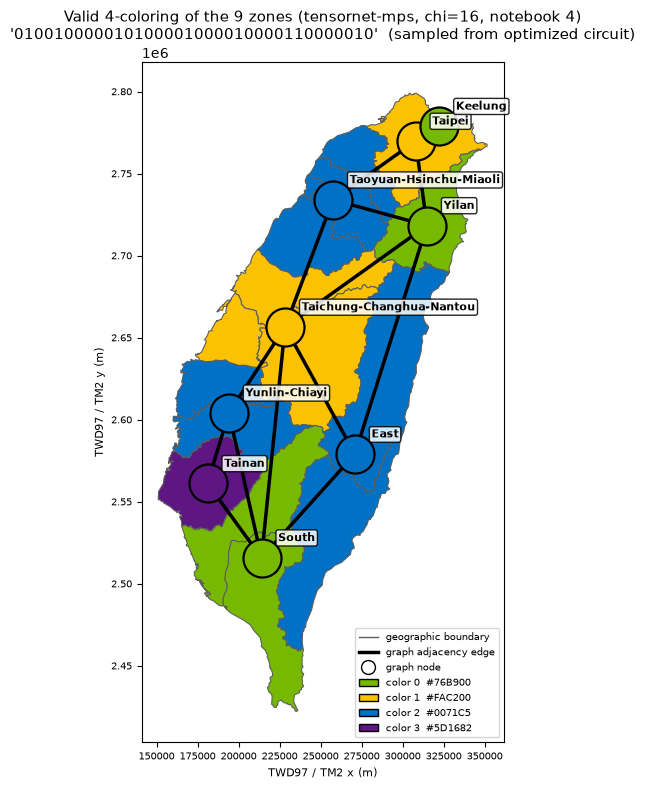

SUMMARY
------------------------------------------------------------------
problem              : 9 zones x 4 colors = 36 qubits, A = 8.0, B = 1.0
backend               : tensornet-mps (fp32), chi=16, abs_cutoff=1e-4
------------------------------------------------------------------
                         notebook 3 (exact)  notebook 4 (chi=16)
s / evaluation                       32.124               12.997
------------------------------------------------------------------
ratio (nb3 / nb4)     : 2.47x
valid-sample rate     : 0.5500% of 2000 shots
------------------------------------------------------------------
verdict: sampled quality matches the exact backend at at-or-below cost, memory footprint
is far smaller (bounded bond dimension), but the MPS readout energy itself is untrustworthy
at this compression -- answers are verified exactly after sampling, via helpers.is_valid,
not by trusting the printed energy.
------------------------------------------------------------------


In [5]:
# cell 5 -- draw the coloring, then report the timing table and verdict.
best_coloring = result["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"), edges=EDGES,
                      node_colors=node_colors, unit_labels=False, color_legend=True,
                      title="Valid 4-coloring of the 9 zones (tensornet-mps, chi=16, notebook 4)\n"
                            f"'{result['best']}'  (sampled from optimized circuit)")
plt.show()

# notebook 3, cell 3 output, this machine, 5 evaluations, exact tensornet backend with path reuse
NB3_SECONDS_PER_EVAL = 32.124
eval_ratio = NB3_SECONDS_PER_EVAL / seconds_per_eval

print("SUMMARY")
print("-" * 66)
print(f"problem              : {N_ZONES} zones x {K} colors = {N} qubits, A = {A}, B = {B}")
print("backend               : tensornet-mps (fp32), chi=16, abs_cutoff=1e-4")
print("-" * 66)
print(f"{'':22s} {'notebook 3 (exact)':>20s} {'notebook 4 (chi=16)':>20s}")
print(f"{'s / evaluation':22s} {NB3_SECONDS_PER_EVAL:20.3f} {seconds_per_eval:20.3f}")
print("-" * 66)
print(f"ratio (nb3 / nb4)     : {eval_ratio:.2f}x")
print(f"valid-sample rate     : {result['valid_rate']:.4%} of {SHOTS} shots")
print("-" * 66)
print("verdict: sampled quality matches the exact backend at at-or-below cost, memory footprint")
print("is far smaller (bounded bond dimension), but the MPS readout energy itself is untrustworthy")
print("at this compression -- answers are verified exactly after sampling, via helpers.is_valid,")
print("not by trusting the printed energy.")
print("-" * 66)